<a href="https://colab.research.google.com/github/khadkaabishek/Machine-Learning-Labs/blob/main/logistic_regression_qn2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
X = np.array([15,29,28,31,35])
Y = np.array(["Fail","Fail","Pass","Pass","Pass"])

In [ ]:
df = pd.DataFrame({"Study Hours":X,"Result":Y})

In [ ]:
df

,Study Hours,Result
0,15,Fail
1,29,Fail
2,28,Pass
3,31,Pass
4,35,Pass


In [ ]:
X = df['Study Hours']
y = df['Result']

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
l = LabelEncoder()

In [ ]:
y=l.fit_transform(y)

In [ ]:
y

array([0, 0, 1, 1, 1])

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.4,random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [ ]:
model.fit(X_train.values.reshape(-5,1),y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test.values.reshape(-1,1))

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import matplotlib.pyplot as plt


In [ ]:
y_pred_prob = model.predict_proba(X_test.values.reshape(-1,1))

In [ ]:
y_pred_prob

array([[1.88371135e-02, 9.81162886e-01],
       [8.81547410e-04, 9.99118453e-01]])

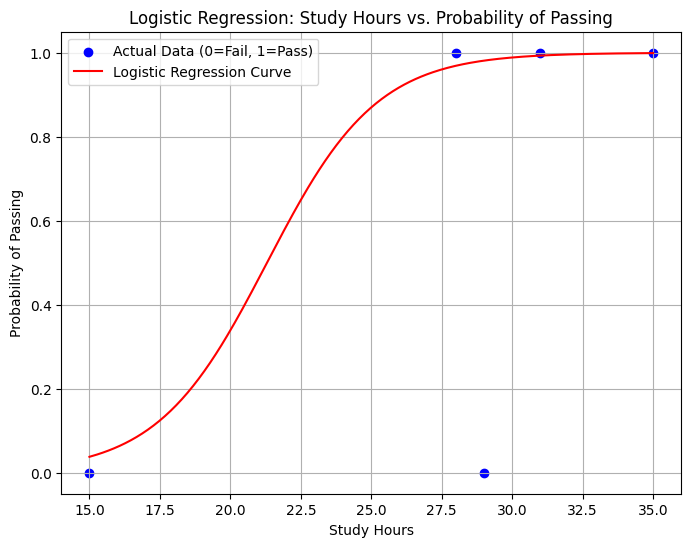

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Actual Data (0=Fail, 1=Pass)')

# Generate a range of study hours for plotting the logistic regression curve
X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_prob_range = model.predict_proba(X_range)[:, 1]

plt.plot(X_range, y_prob_range, color='red', linestyle='-', label='Logistic Regression Curve')

plt.xlabel('Study Hours')
plt.ylabel('Probability of Passing')
plt.title('Logistic Regression: Study Hours vs. Probability of Passing')
plt.legend()
plt.grid(True)
plt.show()